In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
from pathlib import Path
import sys

import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from transformers import AutoTokenizer, AutoModelForCausalLM
from typing import List, Dict, Optional
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from datasets import load_dataset

In [22]:
root = Path.cwd().resolve()
root = root.parent
sys.path.insert(0, str(root))

from sae_trainer.dataset_utils import make_collate_fn, TextDataset, get_data_loaders
from sae_trainer.train_utils import train_sae
from sae_trainer.eval_utils import evaluate_sae, visualize_sae
from sae_trainer.model_utils import SparseAutoencoder
from sae_trainer.activation_collector_utils import GPT2ActivationCollector, QwenActivationCollector

In [23]:
model_name_simple = "qwen" # Either gpt2 or qwen

if model_name_simple == "gpt2":
    model_name = "gpt2"
    collector = GPT2ActivationCollector
elif model_name_simple == "qwen":
    model_name = "Qwen/Qwen2-0.5B-Instruct"
    collector = QwenActivationCollector
else:
    raise ValueError(f"Invalid model name: {model_name_simple}. Expected 'gpt2' or 'qwen'.")


In [24]:
# --- Setup model/tokenizer ---
device = "cuda" if torch.cuda.is_available() else "cpu"
#model_name = "gpt2"  # GPT-2 small: 12 layers, d_model=768 # QWEN: Qwen/Qwen2-0.5B-Instruct

tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2SdpaAttention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
          (rotary_emb): Qwen2RotaryEmbedding()
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((

In [25]:
# --- Example text corpus ---
#texts = [
#    "The Eiffel Tower is in Paris.",
#    "A sparse autoencoder can discover interpretable features.",
#    "Neural networks represent concepts across many layers.",
#    "Attention heads may specialize in different linguistic patterns.",
#    "Residual stream activations are useful for mechanistic interpretability.",
#] * 200  # repeat just for demo

#dataset = TextDataset(texts)
texts = []
ds = load_dataset("wikitext", "wikitext-103-raw-v1", split="train", streaming=True)

#ds = ds.shuffle(seed=42)
#ds = ds.with_format("torch")
for row in ds:
    texts.append(row["text"])
dataset = TextDataset(texts)
loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=False,
    collate_fn=make_collate_fn(tokenizer, max_length=128),
)

In [26]:
# --- Register collector ---
# GPT-2 small has 12 layers (0-11); sample early, mid, late, and final
#target_layers = [3, 6, 9, 11] # GPT-2
#target_layers = [12, 16, 20, 23] # QWEN
#collector = ActivationCollector(
#    model=model,
#    layer_ids=target_layers,
#    capture_residual=True,
#    capture_mlp_down=False,   # set True if you want both
#    to_cpu=True,
#    dtype=torch.float32,
#)
collector = collector(model=model)
target_layers = collector.get_layers()
collector.register()


In [27]:
# --- Dataloader loop to accumulate activations ---
# Stores per-layer chunks, then concatenates at end.
accum = {"residual_out": {i: [] for i in target_layers},
         "mlp_down_out": {i: [] for i in target_layers}}

max_batches = 50  # increase for more data
for step, batch in enumerate(loader):
    if step >= max_batches:
        break

    batch = {k: v.to(device) for k, v in batch.items()}
    acts = collector.collect_batch(batch)

    # Optional: remove pad tokens before append
    # (for now we keep all tokens; filtering can be done later)

    for name in ["residual_out", "mlp_down_out"]:
        for i, x in acts[name].items():
            accum[name][i].append(x)

# concat
for name in ["residual_out", "mlp_down_out"]:
    for i in target_layers:
        if len(accum[name][i]) > 0:
            accum[name][i] = torch.cat(accum[name][i], dim=0)
        else:
            accum[name][i] = None

collector.remove()

for i in target_layers:
    x = accum["residual_out"][i]
    print(f"Layer {i} residual:", None if x is None else tuple(x.shape))

Layer 12 residual: (36864, 896)
Layer 16 residual: (36864, 896)
Layer 20 residual: (36864, 896)
Layer 23 residual: (36864, 896)


In [9]:
# Things to try:

# Decoder column unit norm
# Top-k forward (k~16-32)
# KL to target neuron firing rate

In [28]:
# 0.005 - 0.05
mass_frac_threshold=0.001

# Working combos:
# expansion=8, mass_frac_threshold=0.001
# expansion=16, mass_frac_threshold=0.0005

In [29]:
def training_wrapper(accum, layer_idx, device, mass_frac_threshold, save_filename=None):

    train_loader, val_loader, d_in = get_data_loaders(accum, layer_idx)
    # ---- Model + optimizer ----
    expansion = 8               # 4-16 are common starting points
    d_latent = d_in * expansion # d_in = 3584, so this should be in ~[14k, 60k] (14336-57344)

    sae = SparseAutoencoder(d_in=d_in, d_latent=d_latent).to(device)
    opt = torch.optim.AdamW(sae.parameters(), lr=3e-4, weight_decay=1e-4)

    # Sparsity strength: tune this. Start small.
    lambda_l1 = 1e-2

    # Optional: LR scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=20)

    sae, history = train_sae(
        sae, 
        train_loader, 
        val_loader, 
        opt, 
        scheduler, 
        device, 
        lambda_l1=lambda_l1, 
        mass_frac_threshold=mass_frac_threshold,
        lambda_kl=1e-3,           # tune in log space, e.g. 1e-4 … 1e-2
        target_firing_rate=0.02,  # desired ~soft firing mass per latent
        )

    if save_filename:
        # ---- Save checkpoint ----
        ckpt = {
            "model_state": sae.state_dict(),
            "d_in": d_in,
            "d_latent": d_latent,
            "lambda_l1": lambda_l1,
            "history": history,
        }
        torch.save(ckpt, save_filename)
        print(f"Saved: {save_filename}")

    return sae, history, train_loader, val_loader

Training SAE for layer 12
Epoch 01 | train loss 297.299567 (recon 297.266227, l1 3.208160, kl 1.261868 / 1.204748) | val loss 25.313253 (recon 25.281315, l1 3.073278) | val active 24.5
Epoch 02 | train loss 7.955890 (recon 7.926644, l1 2.805163, kl 1.194092 / 1.187642) | val loss 1.630942 (recon 1.602242, l1 2.751316) | val active 23.6
Epoch 03 | train loss 1.474955 (recon 1.447237, l1 2.652792, kl 1.190303 / 1.192189) | val loss 0.923705 (recon 0.895925, l1 2.658764) | val active 21.4
Epoch 04 | train loss 1.141363 (recon 1.114241, l1 2.592608, kl 1.195781 / 1.196529) | val loss 1.219154 (recon 1.192005, l1 2.595203) | val active 21.2
Epoch 05 | train loss 0.744882 (recon 0.718334, l1 2.534922, kl 1.198568 / 1.198369) | val loss 0.632436 (recon 0.605780, l1 2.545783) | val active 21.4
Epoch 06 | train loss 0.647771 (recon 0.621643, l1 2.492697, kl 1.200981 / 1.199869) | val loss 0.624587 (recon 0.598308, l1 2.507984) | val active 22.3
Epoch 07 | train loss 0.464388 (recon 0.438653, l1

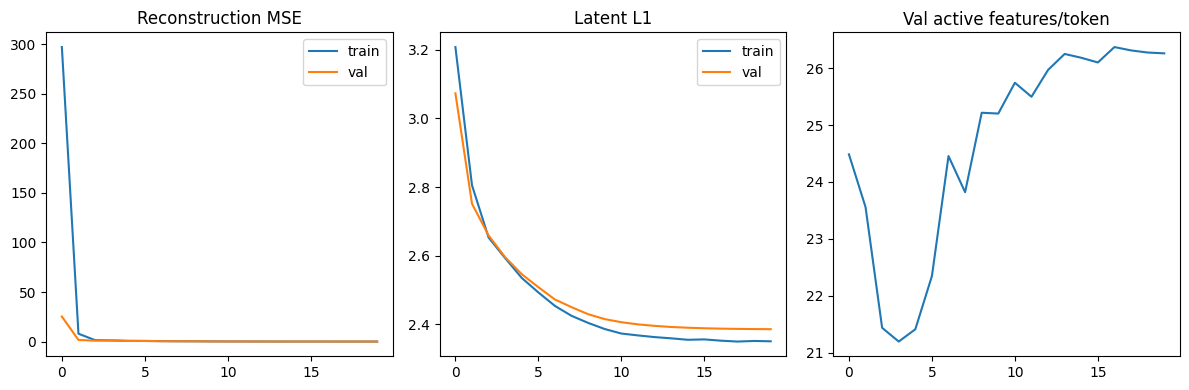

Saved: sae_qwen_layer12.pt
Training SAE for layer 16
Epoch 01 | train loss 254.831487 (recon 254.798930, l1 3.129813, kl 1.257873 / 1.194099) | val loss 16.551323 (recon 16.520445, l1 2.968335) | val active 26.6
Epoch 02 | train loss 6.839050 (recon 6.810624, l1 2.724440, kl 1.182129 / 1.176572) | val loss 1.862977 (recon 1.835219, l1 2.658087) | val active 30.1
Epoch 03 | train loss 1.452026 (recon 1.425036, l1 2.580859, kl 1.181191 / 1.185162) | val loss 1.130409 (recon 1.103240, l1 2.598457) | val active 28.0
Epoch 04 | train loss 1.073144 (recon 1.046715, l1 2.523858, kl 1.190955 / 1.192789) | val loss 0.813062 (recon 0.786533, l1 2.533637) | val active 27.8
Epoch 05 | train loss 0.680310 (recon 0.654354, l1 2.475907, kl 1.197012 / 1.198112) | val loss 0.664661 (recon 0.638580, l1 2.488243) | val active 28.6
Epoch 06 | train loss 0.495950 (recon 0.470384, l1 2.436315, kl 1.202596 / 1.202988) | val loss 0.600913 (recon 0.575152, l1 2.455765) | val active 30.4
Epoch 07 | train loss 0

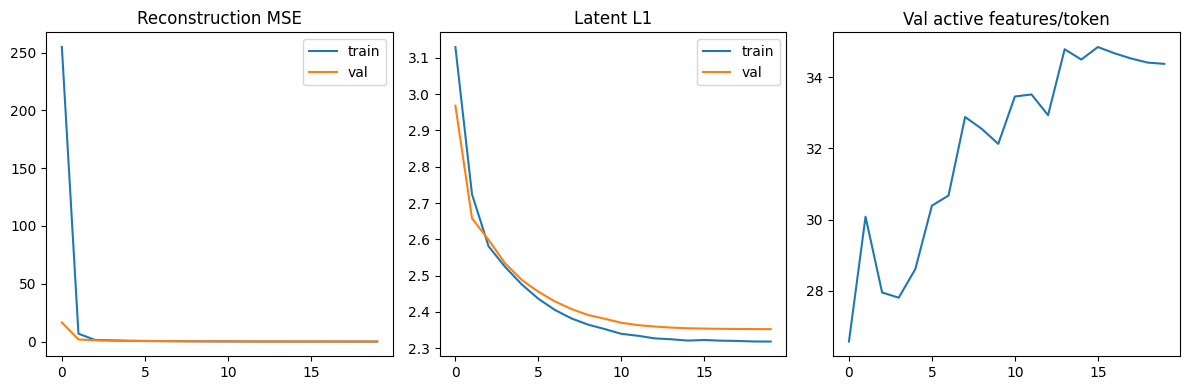

Saved: sae_qwen_layer16.pt
Training SAE for layer 20
Epoch 01 | train loss 282.895071 (recon 282.861569, l1 3.222558, kl 1.280307 / 1.199930) | val loss 21.433104 (recon 21.401211, l1 3.069338) | val active 24.3
Epoch 02 | train loss 7.752159 (recon 7.722855, l1 2.812180, kl 1.182845 / 1.176724) | val loss 1.998633 (recon 1.969998, l1 2.745877) | val active 33.3
Epoch 03 | train loss 1.762255 (recon 1.734466, l1 2.660396, kl 1.185430 / 1.192836) | val loss 1.151740 (recon 1.123804, l1 2.674314) | val active 33.6
Epoch 04 | train loss 1.293547 (recon 1.266259, l1 2.608442, kl 1.203682 / 1.207594) | val loss 1.450536 (recon 1.423200, l1 2.612859) | val active 34.0
Epoch 05 | train loss 0.929865 (recon 0.903080, l1 2.557155, kl 1.214163 / 1.216715) | val loss 0.773530 (recon 0.746660, l1 2.565380) | val active 34.4
Epoch 06 | train loss 0.597405 (recon 0.570982, l1 2.519820, kl 1.224852 / 1.227639) | val loss 0.541944 (recon 0.515358, l1 2.535879) | val active 34.6
Epoch 07 | train loss 0

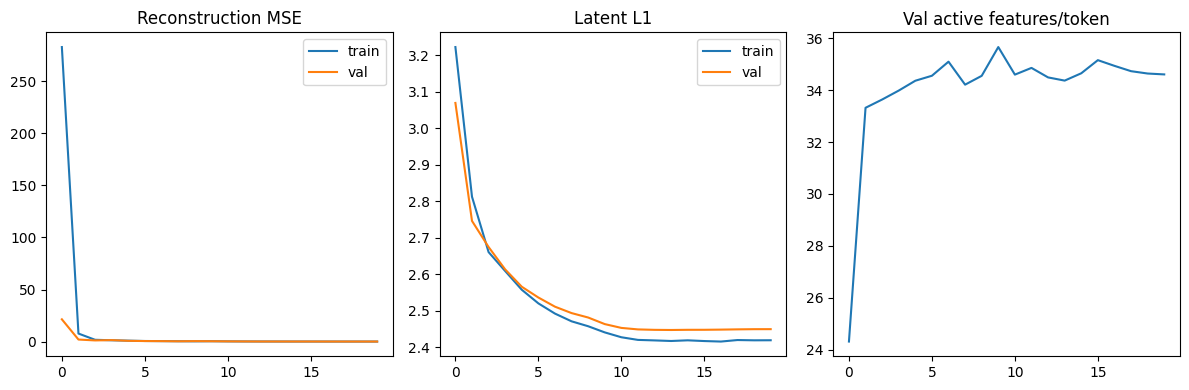

Saved: sae_qwen_layer20.pt
Training SAE for layer 23
Epoch 01 | train loss 3.717016 (recon 3.711379, l1 0.446624, kl 1.170184 / 1.041689) | val loss 1.252361 (recon 1.247584, l1 0.373581) | val active 108.7
Epoch 02 | train loss 0.917630 (recon 0.913151, l1 0.347302, kl 1.005831 / 0.987190) | val loss 0.645145 (recon 0.640838, l1 0.331982) | val active 145.2
Epoch 03 | train loss 0.503919 (recon 0.499648, l1 0.328083, kl 0.990167 / 0.995054) | val loss 0.416222 (recon 0.411969, l1 0.325866) | val active 146.5
Epoch 04 | train loss 0.326352 (recon 0.322058, l1 0.328625, kl 1.008225 / 1.020628) | val loss 0.303497 (recon 0.299159, l1 0.331666) | val active 138.2
Epoch 05 | train loss 0.235042 (recon 0.230647, l1 0.336085, kl 1.034382 / 1.045705) | val loss 0.238187 (recon 0.233746, l1 0.339561) | val active 130.7
Epoch 06 | train loss 0.181223 (recon 0.176722, l1 0.344352, kl 1.057992 / 1.066797) | val loss 0.196060 (recon 0.191520, l1 0.347370) | val active 127.2
Epoch 07 | train loss 0

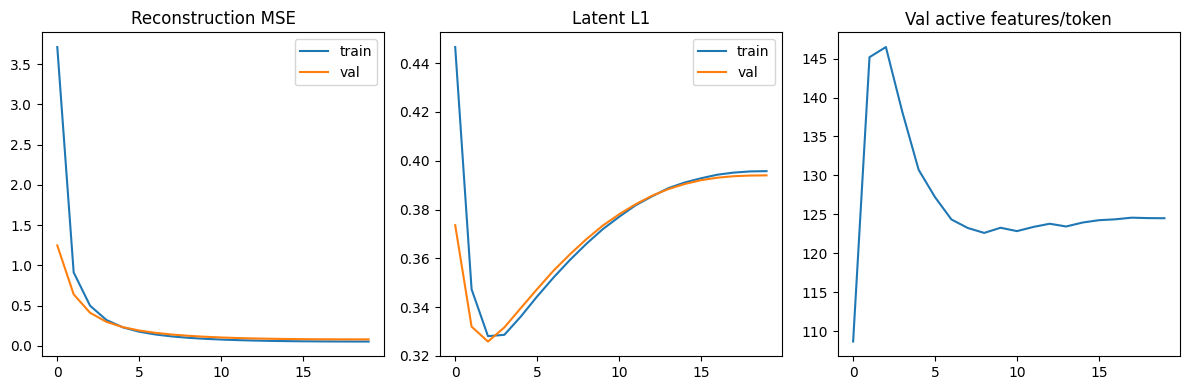

Saved: sae_qwen_layer23.pt


In [30]:
saes = {}
histories = {}
train_loaders = {}
val_loaders = {}

for target_layer in target_layers:
    print(f"Training SAE for layer {target_layer}")
    sae, history, train_loader, val_loader = training_wrapper(accum, target_layer, device, mass_frac_threshold, save_filename=f'sae_{model_name_simple}_layer{target_layer}.pt')
    saes[target_layer] = sae
    histories[target_layer] = history
    train_loaders[target_layer] = train_loader
    val_loaders[target_layer] = val_loader


=== SAE Metrics ===
                             mse: 0.008564
              explained_variance: 0.999989
                   avg_l1_latent: 2.351109
   avg_active_features_per_token: 25.897748
               dead_feature_rate: 0.898717
                   usage_entropy: 4.485635
                usage_perplexity: 88.733261


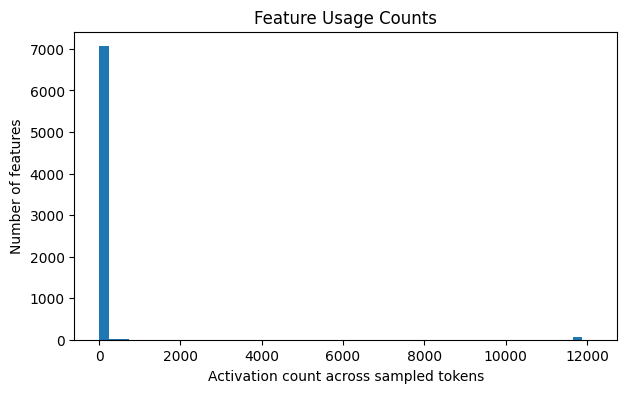

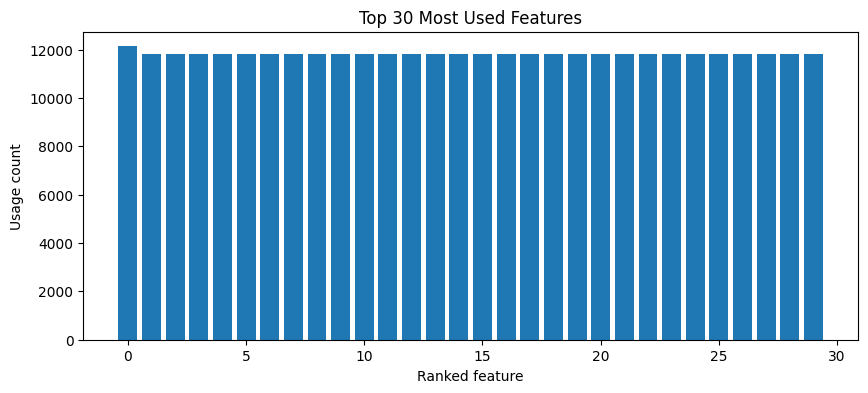

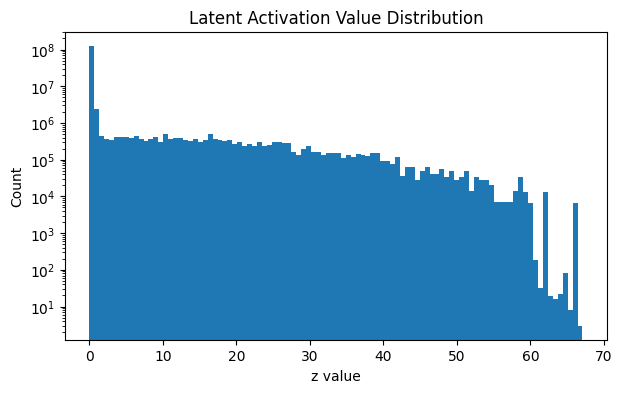

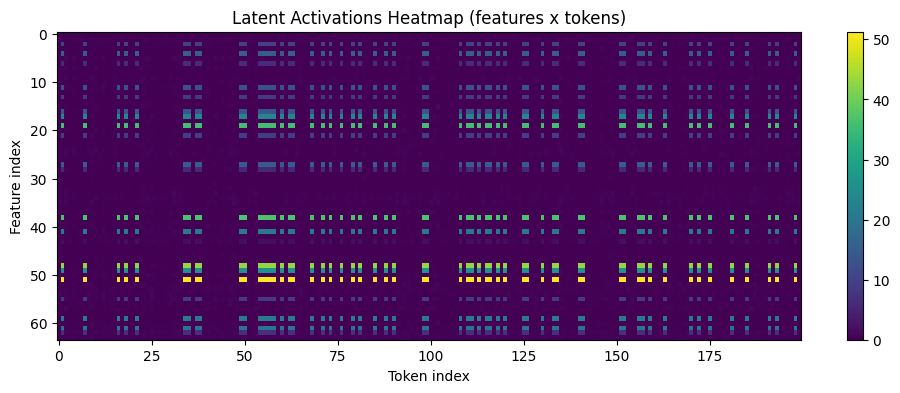

UMAP not installed. `pip install umap-learn` to enable latent-space plot.
=== SAE Metrics ===
                             mse: 0.016374
              explained_variance: 0.999980
                   avg_l1_latent: 2.319614
   avg_active_features_per_token: 33.804774
               dead_feature_rate: 0.795480
                   usage_entropy: 4.793484
                usage_perplexity: 120.721198


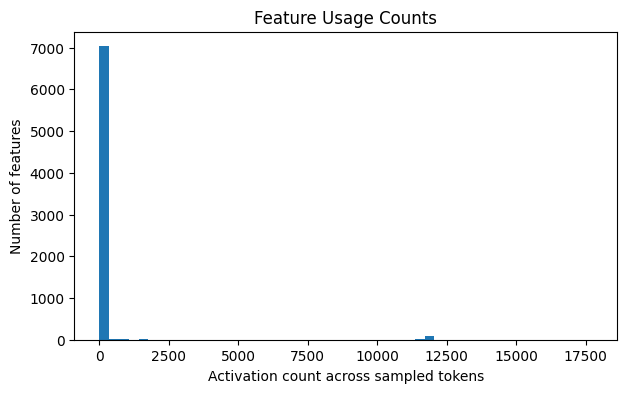

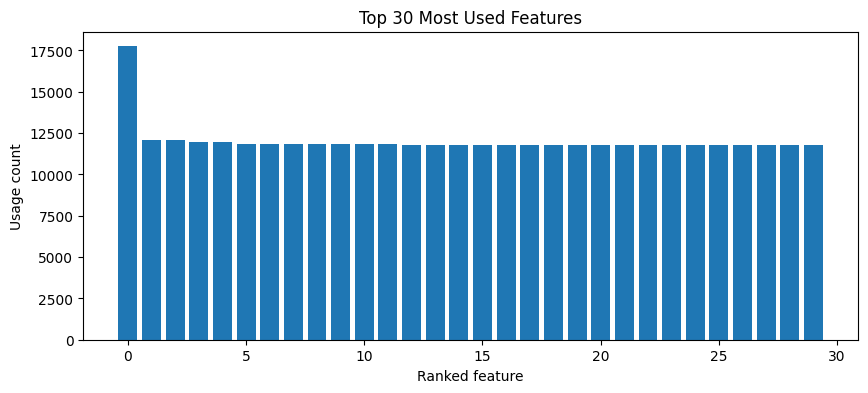

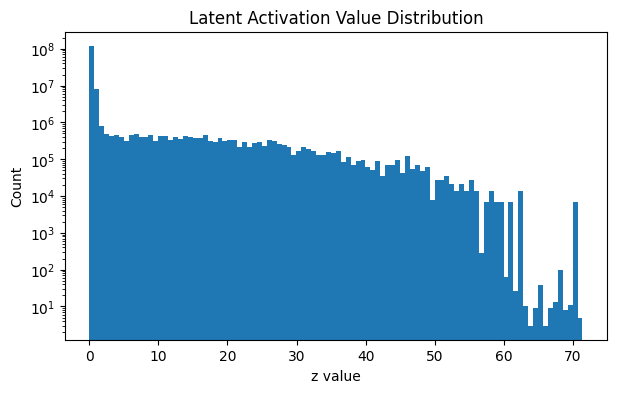

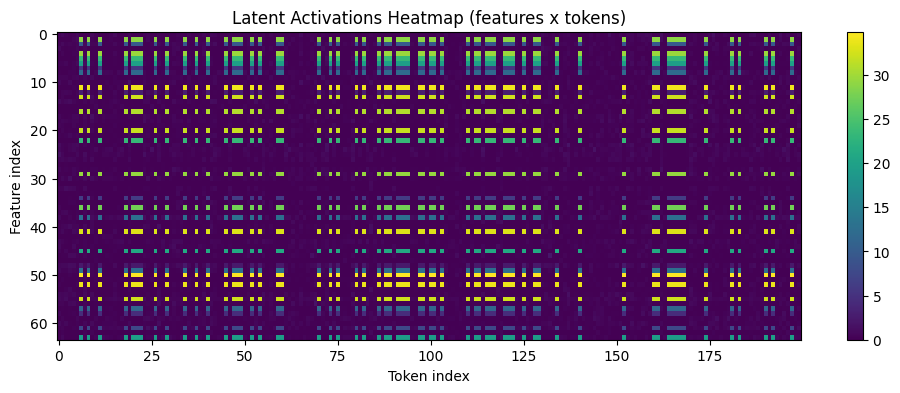

UMAP not installed. `pip install umap-learn` to enable latent-space plot.
=== SAE Metrics ===
                             mse: 0.036631
              explained_variance: 0.999954
                   avg_l1_latent: 2.417800
   avg_active_features_per_token: 34.087747
               dead_feature_rate: 0.791574
                   usage_entropy: 4.776352
                usage_perplexity: 118.670640


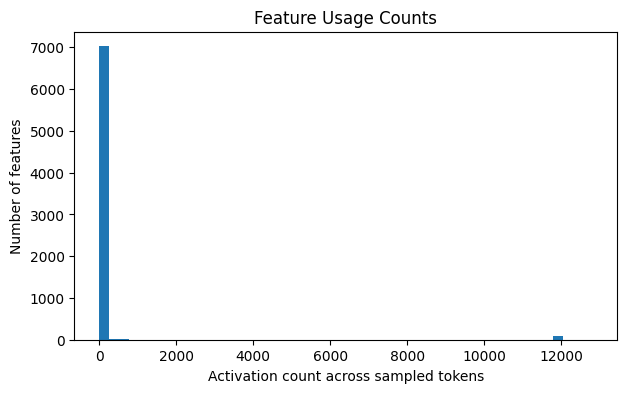

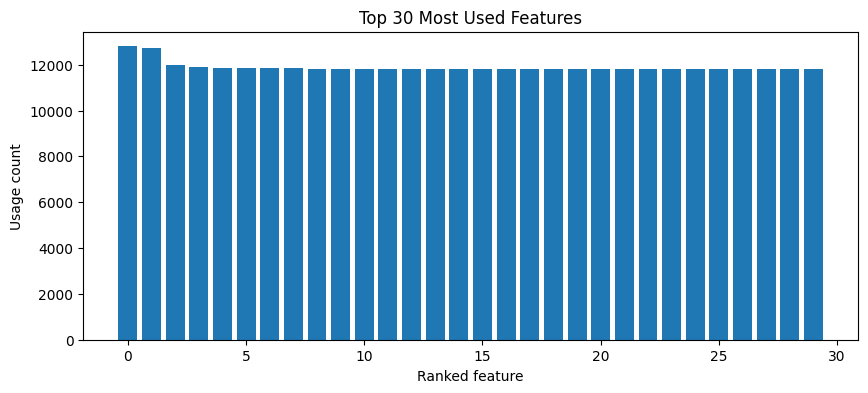

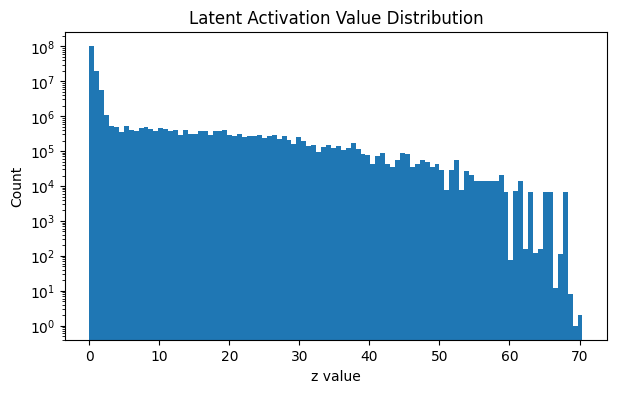

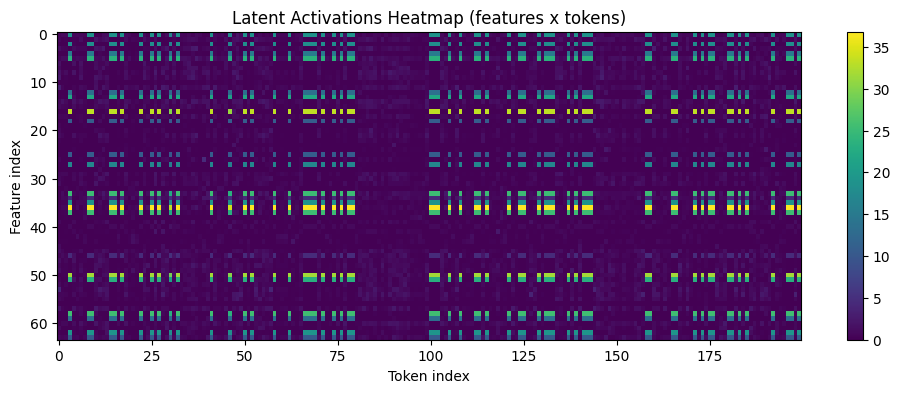

UMAP not installed. `pip install umap-learn` to enable latent-space plot.
=== SAE Metrics ===
                             mse: 0.054399
              explained_variance: 0.993596
                   avg_l1_latent: 0.395704
   avg_active_features_per_token: 122.774500
               dead_feature_rate: 0.387695
                   usage_entropy: 6.002761
                usage_perplexity: 404.544154


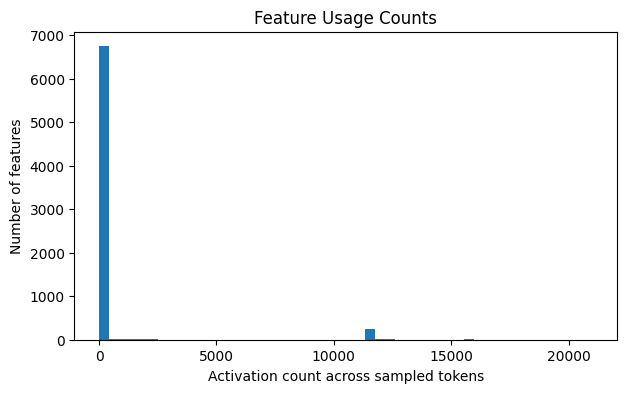

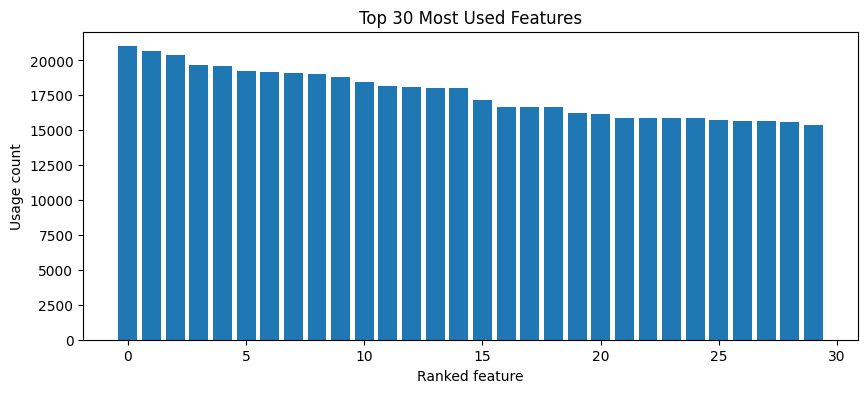

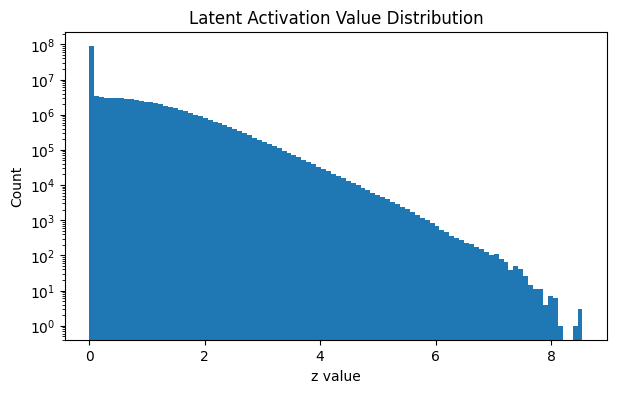

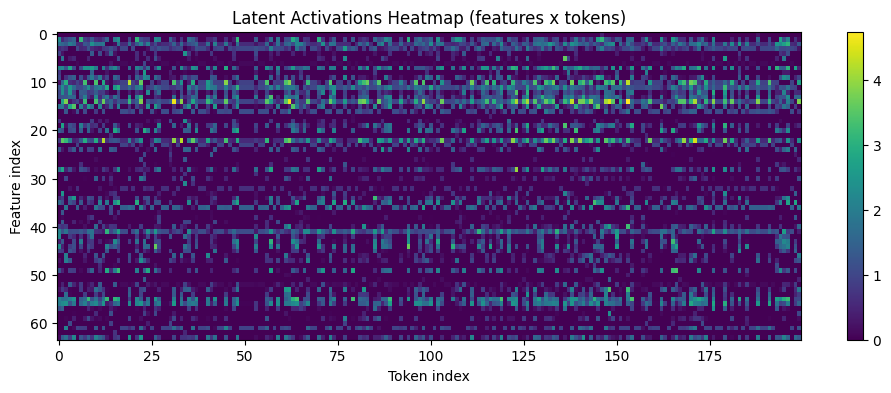

UMAP not installed. `pip install umap-learn` to enable latent-space plot.


In [31]:
# Evaluate and visualize SAEs
for target_layer in target_layers:
    metrics = evaluate_sae(saes[target_layer], train_loaders[target_layer], device, mass_frac_threshold=mass_frac_threshold, show_metrics=True)
    visualize_sae(metrics)
